In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

deep_silu = nn.Sequential(
    nn.Linear(512, 256),
    nn.SiLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.SiLU(),
    nn.Linear(128, 9),
)

In [3]:
res_mod_silu = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod_silu.named_children():
     if name == 'fc':
         print(name + ' has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

res_mod_silu.fc = deep_silu

res_mod_silu = res_mod_silu.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, res_mod_silu.parameters()), lr=0.0001, weight_decay=0.0001)
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_silu, T_max=30, eta_min=1e-6)

fc has been unfrozen.


In [4]:
deep_silu_mod, metrics_silu = train_model(res_mod_silu, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.0798 | Acc: 0.6230 | Weighted Acc: 0.5798 | F1-macro: 0.6218 | Top-1 Acc: 0.6230 | Top-3 Acc: 0.8933
Epoch Time: 23.3616s

Training complete in 9m 48s
Best val Weighted Acc: 0.594248 | Best F1-score: 0.6379 | Best Top-1 Acc: 0.6376 | Best Top-3 Acc: 0.8933


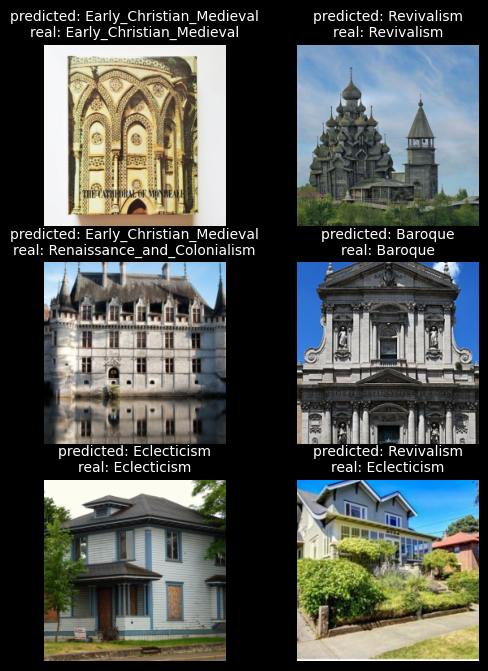

In [5]:
visualize_model(deep_silu_mod, num_images=6, class_names=class_names, vis_loader=vis_loader)

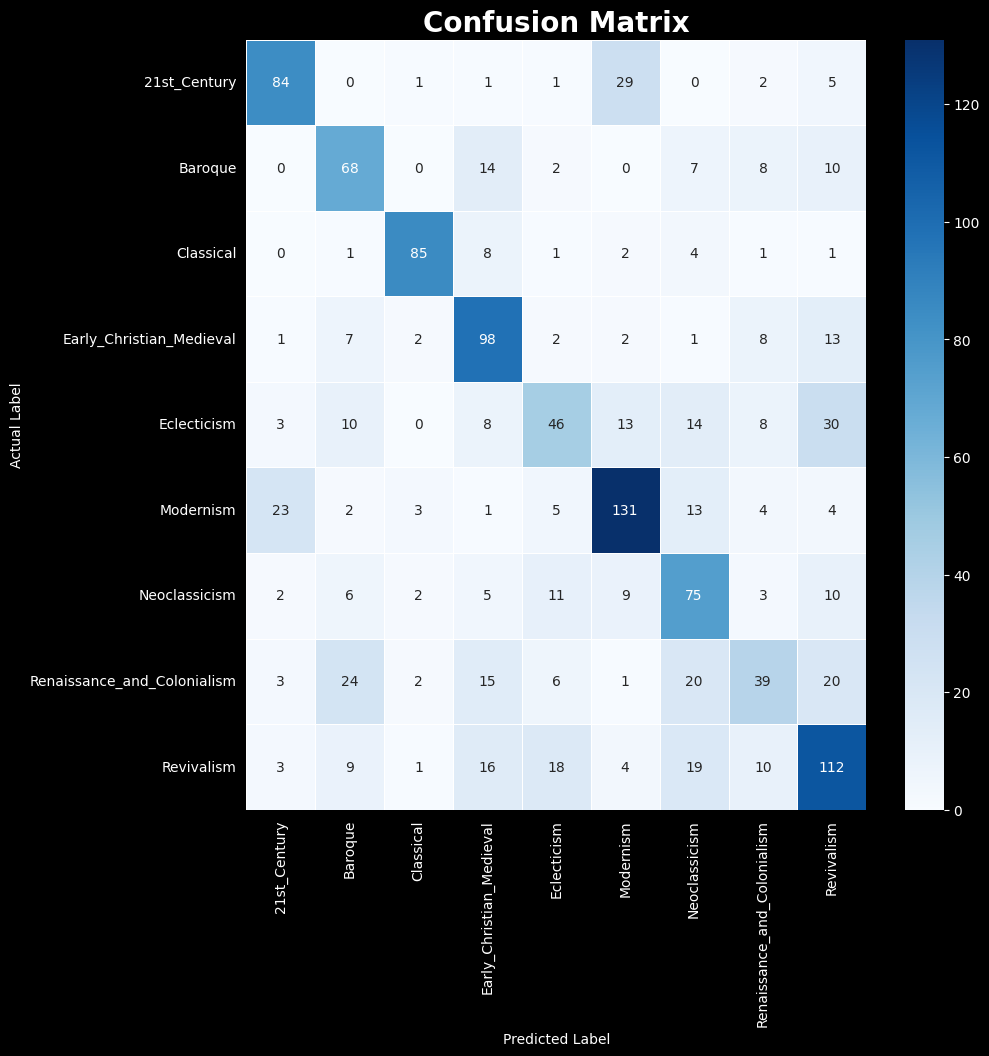

In [6]:
visualize_cm(deep_silu_mod, class_names, test_set)

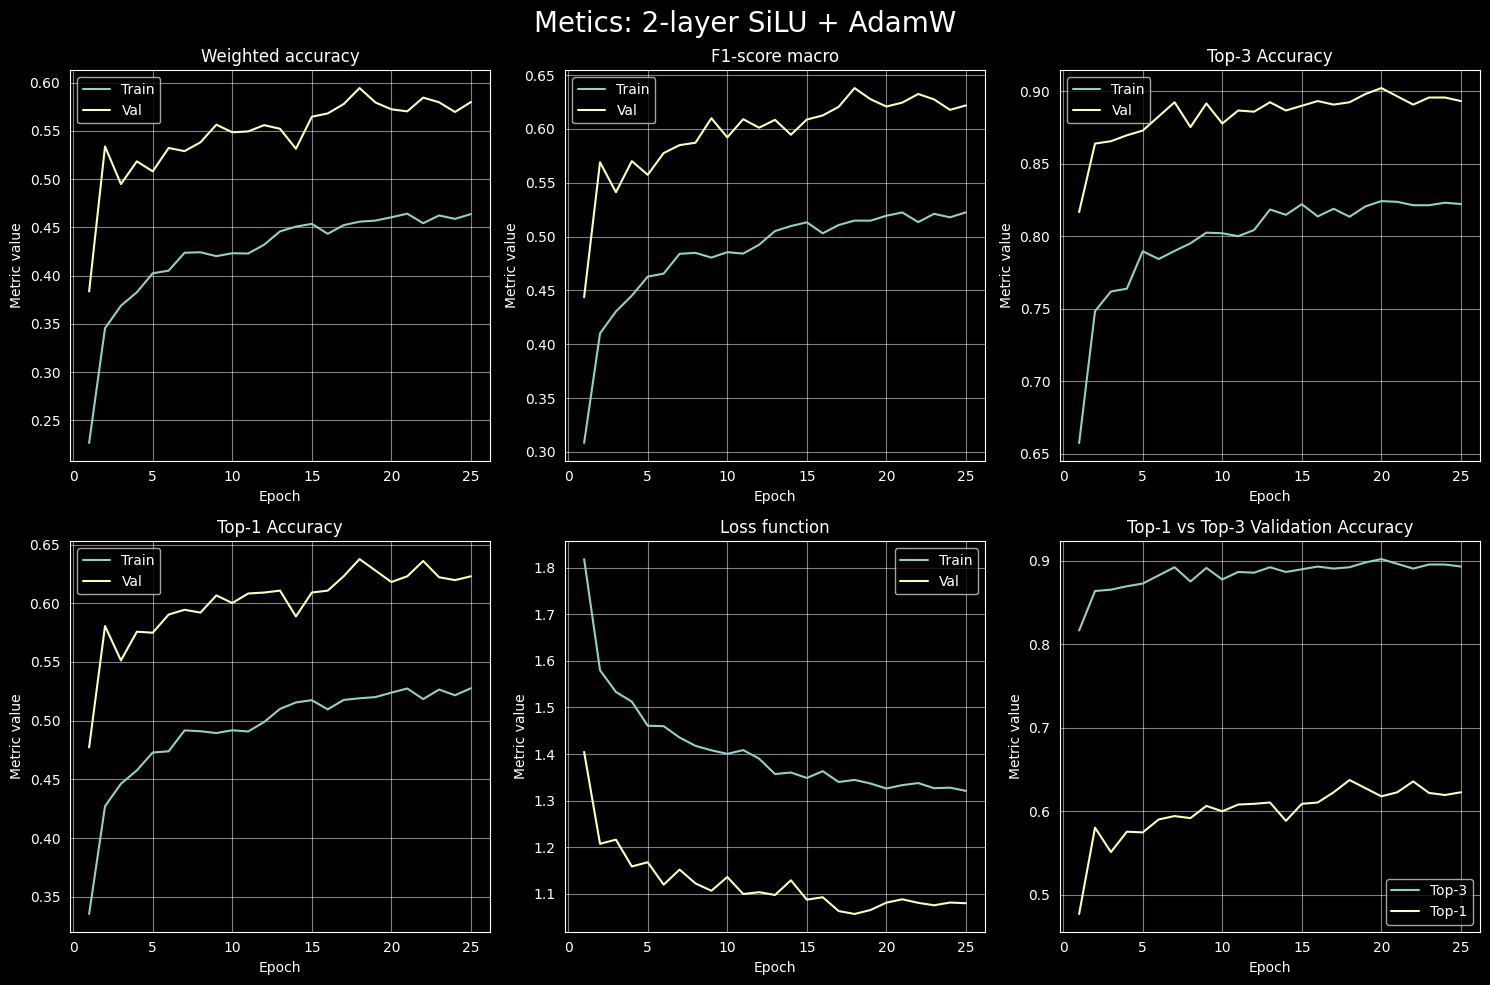

In [7]:
visualize_metrics(metrics_silu, "Metics: 2-layer SiLU + AdamW", 25)

# lr = 3e-4, weight_decay = 3e-5

In [8]:
cur_mod = deep_silu_mod.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=0.0003, weight_decay=0.00003)
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_silu, T_max=30, eta_min=1e-6)

In [9]:
deep_silu_v2, metrics_v2 = train_model(cur_mod, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.0062 | Acc: 0.6580 | Weighted Acc: 0.6094 | F1-macro: 0.6554 | Top-1 Acc: 0.6580 | Top-3 Acc: 0.9137
Epoch Time: 23.7460s

Training complete in 9m 48s
Best val Weighted Acc: 0.619061 | Best F1-score: 0.6591 | Best Top-1 Acc: 0.6604 | Best Top-3 Acc: 0.9080


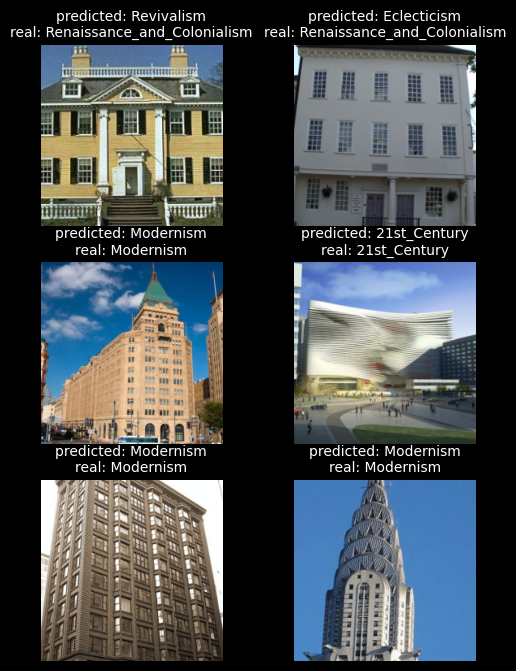

In [10]:
visualize_model(deep_silu_v2, num_images=6, class_names=class_names, vis_loader=vis_loader)

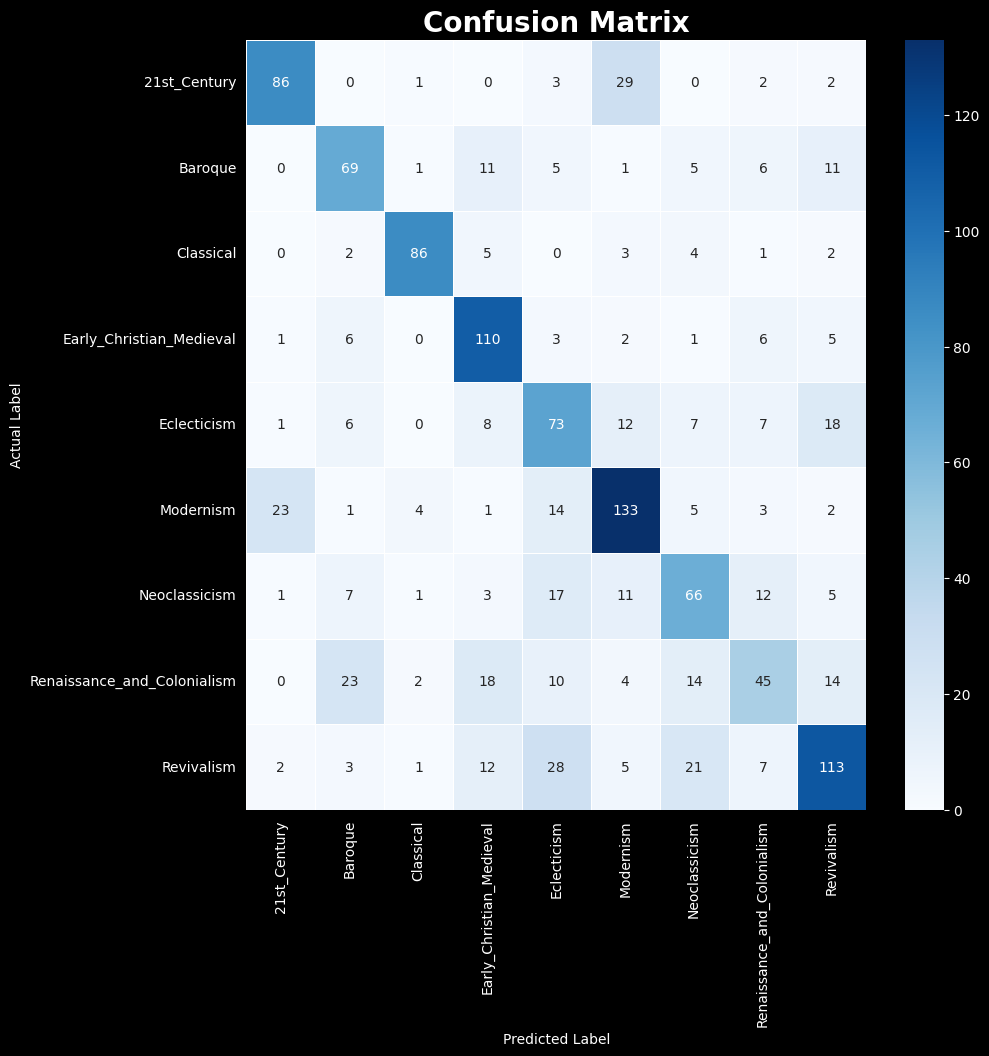

In [11]:
visualize_cm(deep_silu_v2, class_names, test_set)

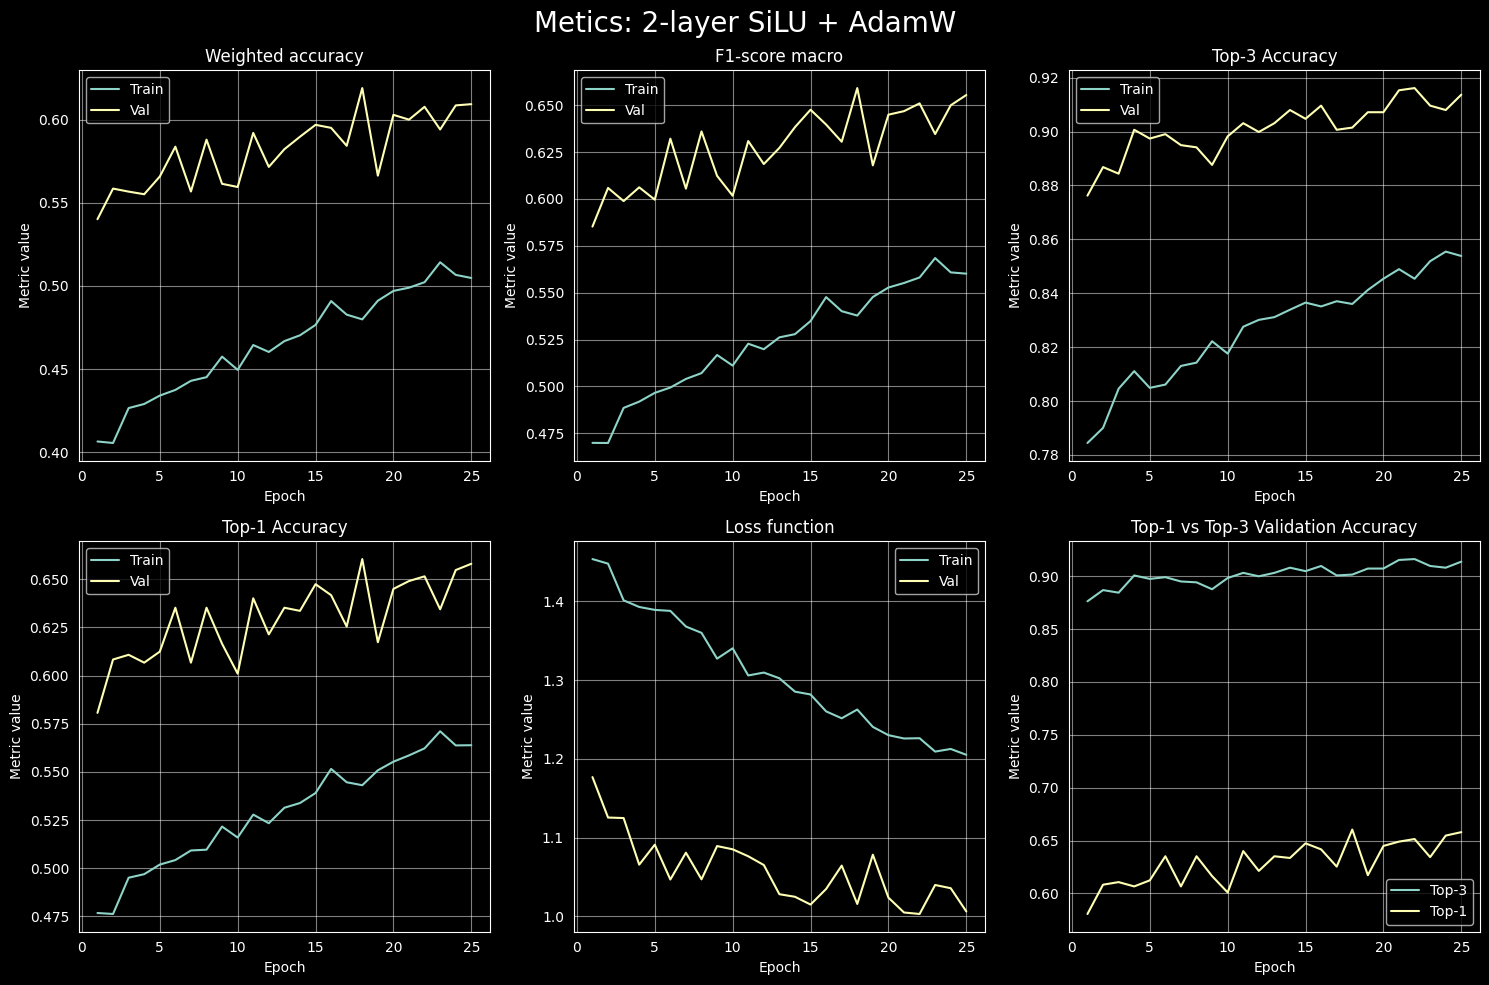

In [12]:
visualize_metrics(metrics_v2, "Metics: 2-layer SiLU + AdamW", 25)

# fine tuning

In [13]:
cur_mod = deep_silu_v2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=1e-4,
                                   weight_decay=3e-5)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
deep_silu_v2_ft, metrics_v2_ft = train_model(cur_mod, criterion, optimizer, scheduler, dataloaders,
                                             dataset_sizes,
                                             25)

val Loss: 1.0394 | Acc: 0.6523 | Weighted Acc: 0.6066 | F1-macro: 0.6506 | Top-1 Acc: 0.6523 | Top-3 Acc: 0.9161
Epoch Time: 23.3924s

Training complete in 9m 54s
Best val Weighted Acc: 0.628806 | Best F1-score: 0.6711 | Best Top-1 Acc: 0.6735 | Best Top-3 Acc: 0.9121


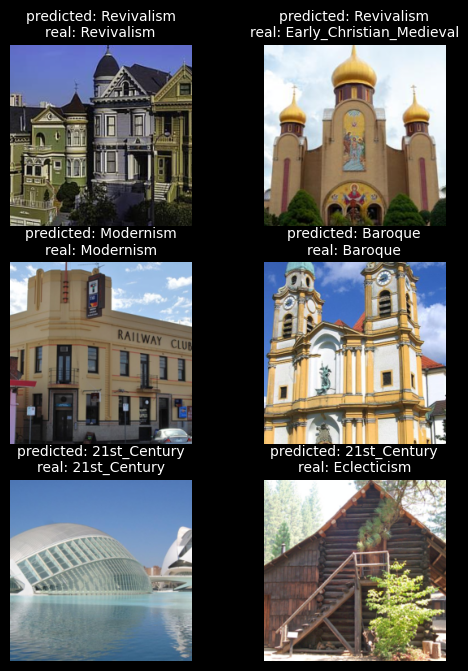

In [14]:
visualize_model(deep_silu_v2_ft, num_images=6, class_names=class_names, vis_loader=vis_loader)

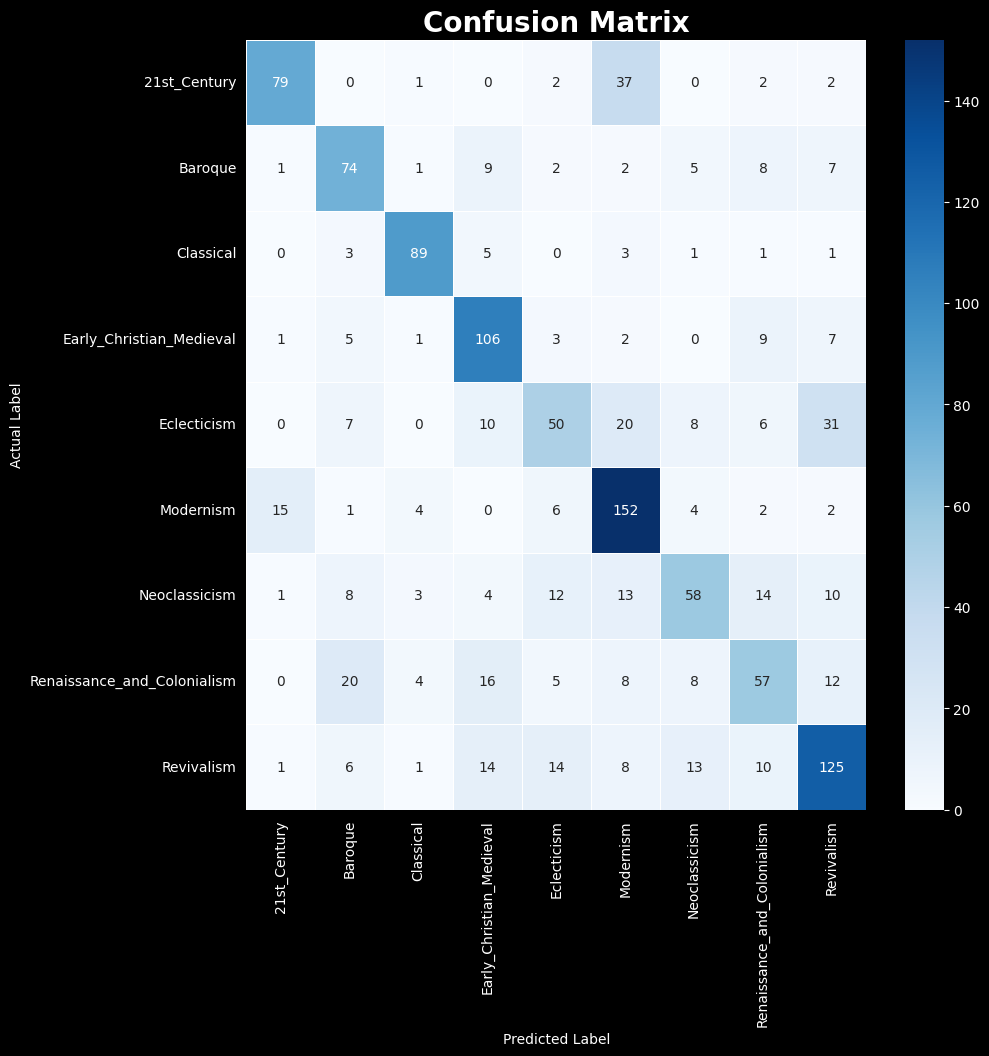

In [15]:
visualize_cm(deep_silu_v2_ft, class_names, test_set)

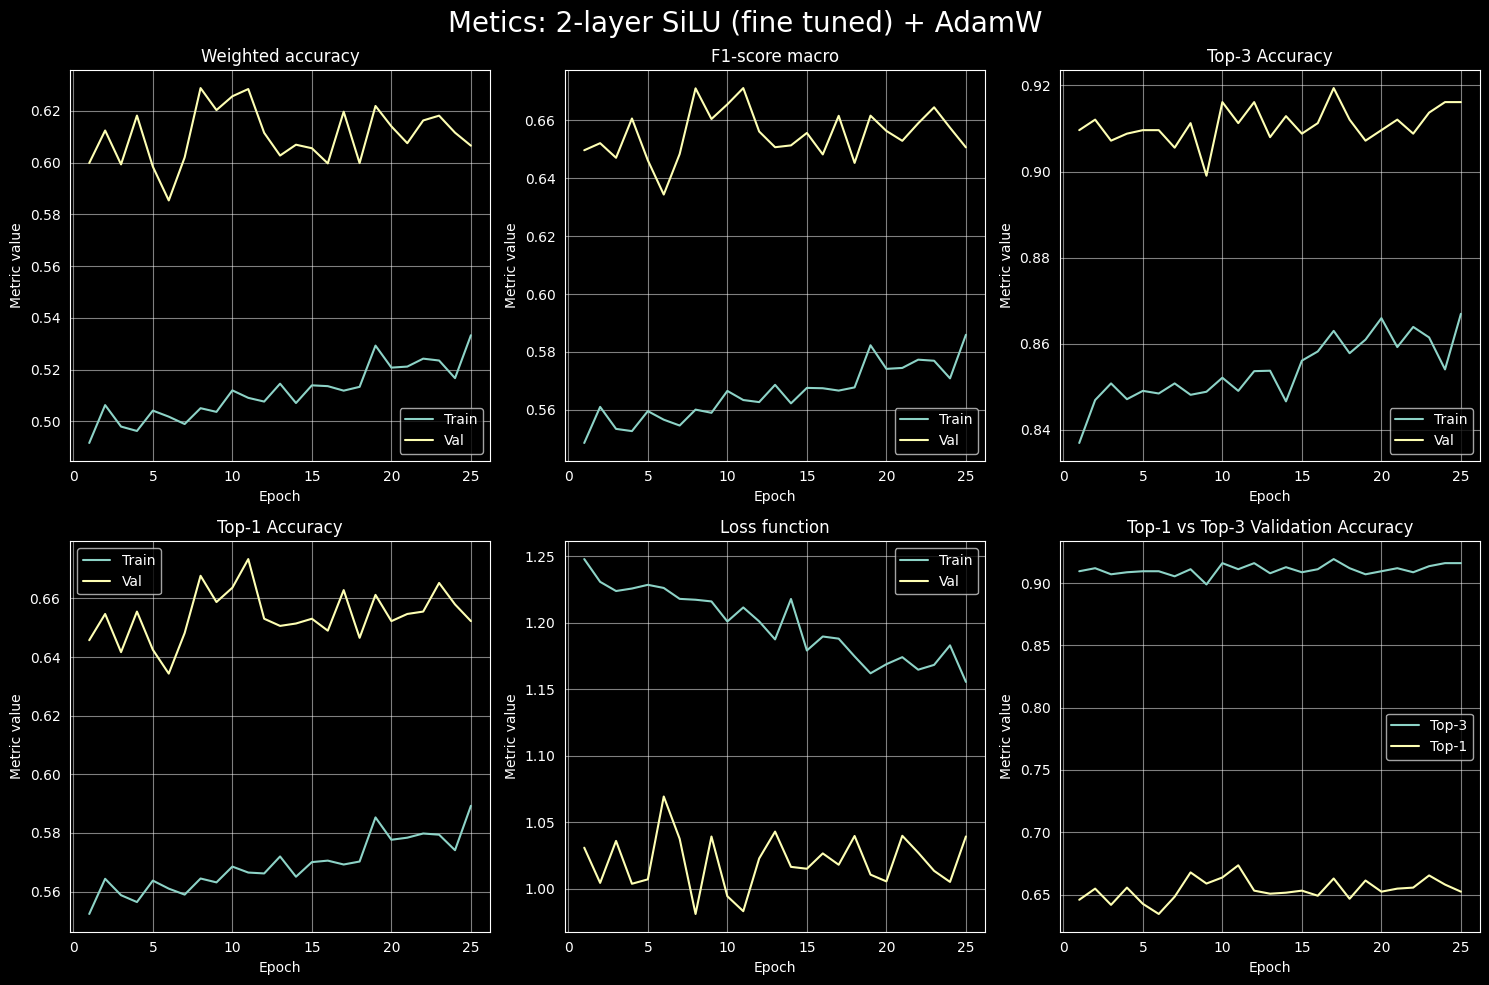

In [16]:
visualize_metrics(metrics_v2_ft, "Metics: 2-layer SiLU (fine tuned) + AdamW", 25)

In [22]:
torch.save(deep_silu_v2_ft, 'best_deep_silu_v2_ft.pt')

# fine tuning 2

In [17]:
cur_mod = deep_silu_v2_ft.to(device)

optimizer = torch.optim.AdamW(
    filter(lambda x: x.requires_grad, cur_mod.parameters()),
    lr=3e-5,
    weight_decay=3e-4
)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-7)

deep_silu_v3, metrics_v3 = train_model(cur_mod, criterion, optimizer, scheduler,
                                     dataloaders, dataset_sizes, 40)

val Loss: 1.0153 | Acc: 0.6564 | Weighted Acc: 0.6142 | F1-macro: 0.6570 | Top-1 Acc: 0.6564 | Top-3 Acc: 0.9137
Epoch Time: 23.3671s

Training complete in 15m 43s
Best val Weighted Acc: 0.632674 | Best F1-score: 0.6710 | Best Top-1 Acc: 0.6702 | Best Top-3 Acc: 0.9153


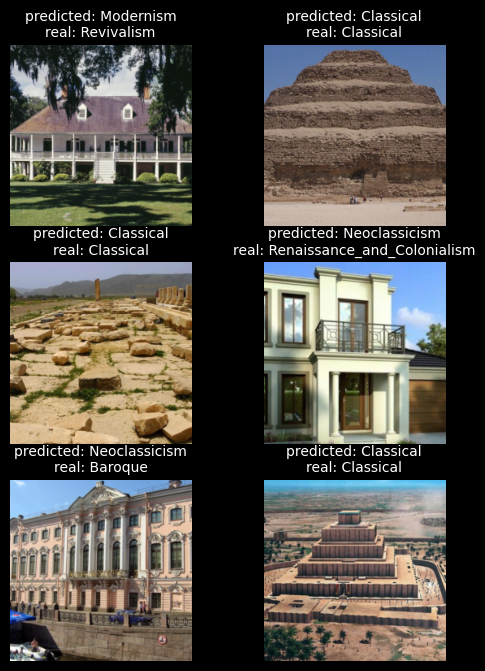

In [18]:
visualize_model(deep_silu_v3, num_images=6, class_names=class_names, vis_loader=vis_loader)

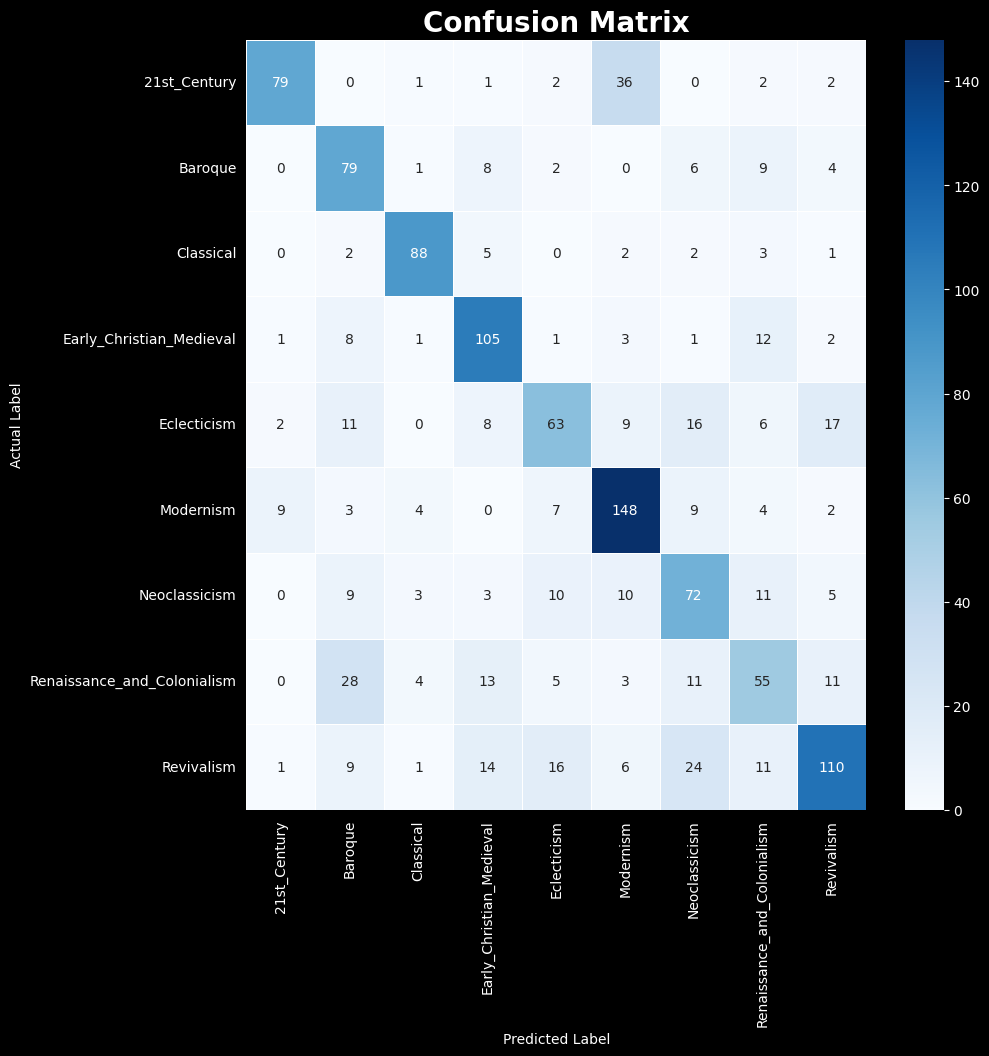

In [19]:
visualize_cm(deep_silu_v3, class_names, test_set)

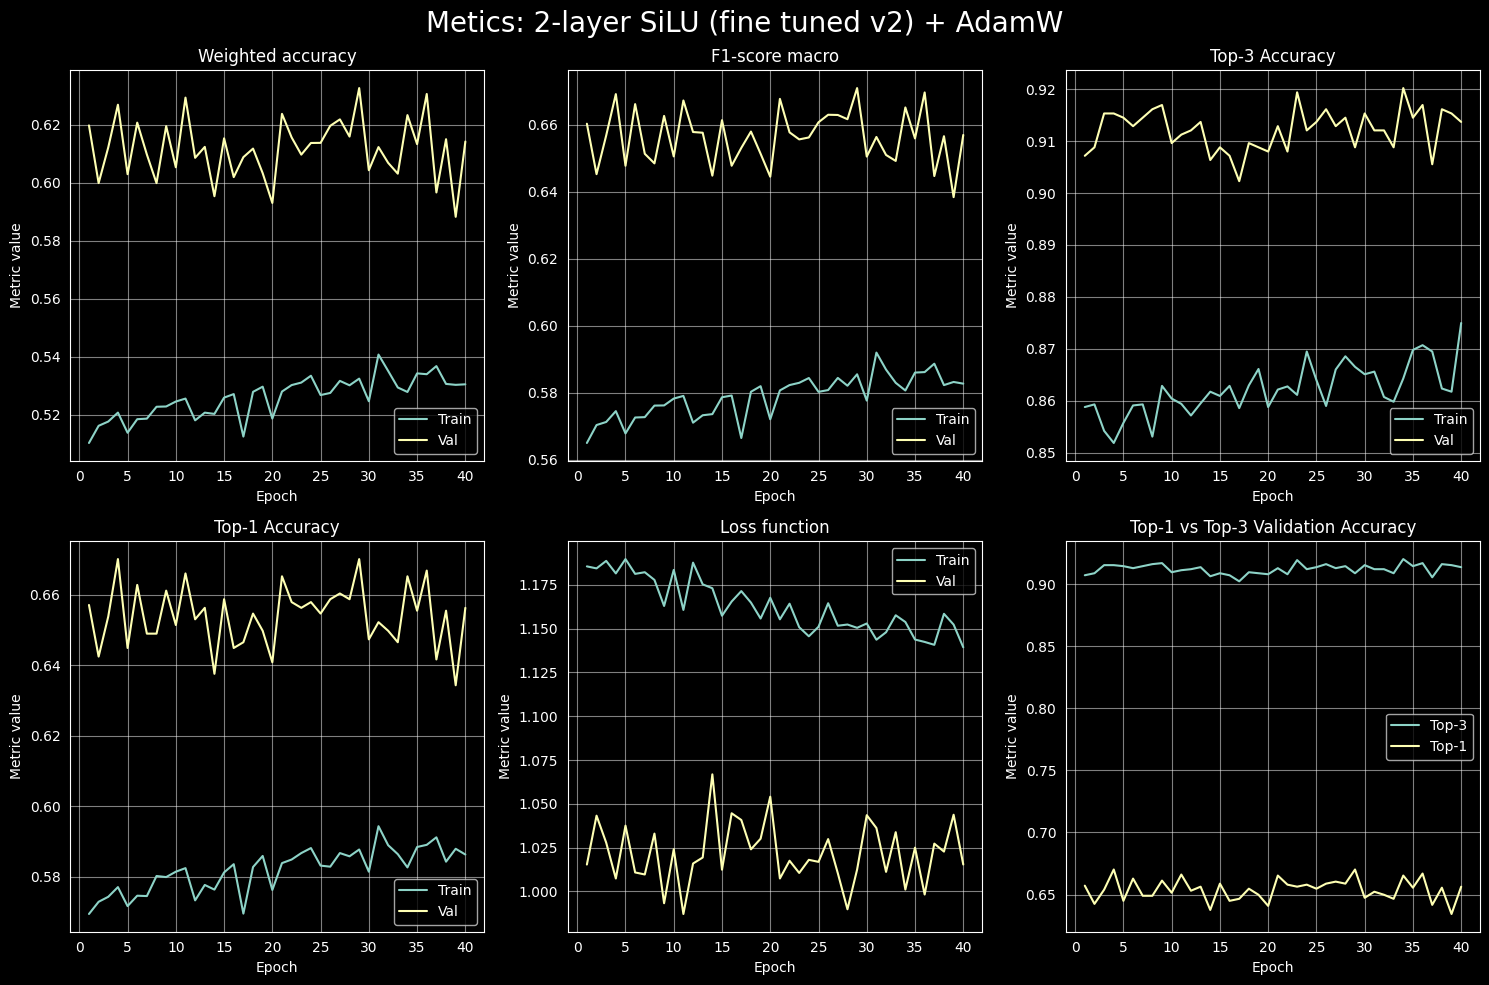

In [21]:
visualize_metrics(metrics_v3, "Metics: 2-layer SiLU (fine tuned v2) + AdamW", 40)